# Dynamic Coefficient Analysis: How Feature Impacts Evolve Over Time

This notebook examines how the regression coefficients of key housing features change over construction years. 
It analyzes both House_Price and Price_Per_Sqft to understand temporal heterogeneity in feature importance.

**Key Objectives:**
- Perform yearly grouped OLS regressions
- Track coefficient evolution over time
- Identify features with statistically significant trends
- Provide insights for dynamic pricing and market analysis

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

# Plot settings
plt.style.use('seaborn-v0_8')
%matplotlib inline

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Project paths
data_path = Path('../../data/processed/house_price_reg_processed.csv')
figures_dir = Path('../../results/figures/')

# Create output directory
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"Data path: {data_path}")
print(f"Figures will be saved to: {figures_dir}")

Data path: ..\..\data\processed\house_price_reg_processed.csv
Figures will be saved to: ..\..\results\figures


In [4]:
# Load processed data
df = pd.read_csv(data_path)
print(f"Dataset loaded: {df.shape[0]:,} observations")

# Define explanatory variables (excluding House_Age and Year_Built as time dimension)
exog_vars = ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Lot_Size', 'Garage_Size']

Dataset loaded: 1,000 observations


In [5]:
# ====================== Yearly Grouped Regression ======================
def year_regression(data, dependent_var):
    """Run OLS regression for a given year/group"""
    X = sm.add_constant(data[exog_vars])
    y = data[dependent_var]
    model = sm.OLS(y, X).fit()
    return pd.Series({
        'R2': model.rsquared,
        'F_value': model.fvalue,
        **{f'coef_{var}': model.params[var] for var in exog_vars},
        **{f'pvalue_{var}': model.pvalues[var] for var in exog_vars}
    })

# Apply regression by Year_Built
print("Running yearly regressions...")

year_models_price = (
    df.groupby('Year_Built')
    .apply(lambda x: year_regression(x, 'House_Price'), include_groups=False)
)

year_models_sqft = (
    df.groupby('Year_Built')
    .apply(lambda x: year_regression(x, 'Price_Per_Sqft'), include_groups=False)
)

print(f"Completed regressions for {len(year_models_price)} years.")

Running yearly regressions...
Completed regressions for 73 years.


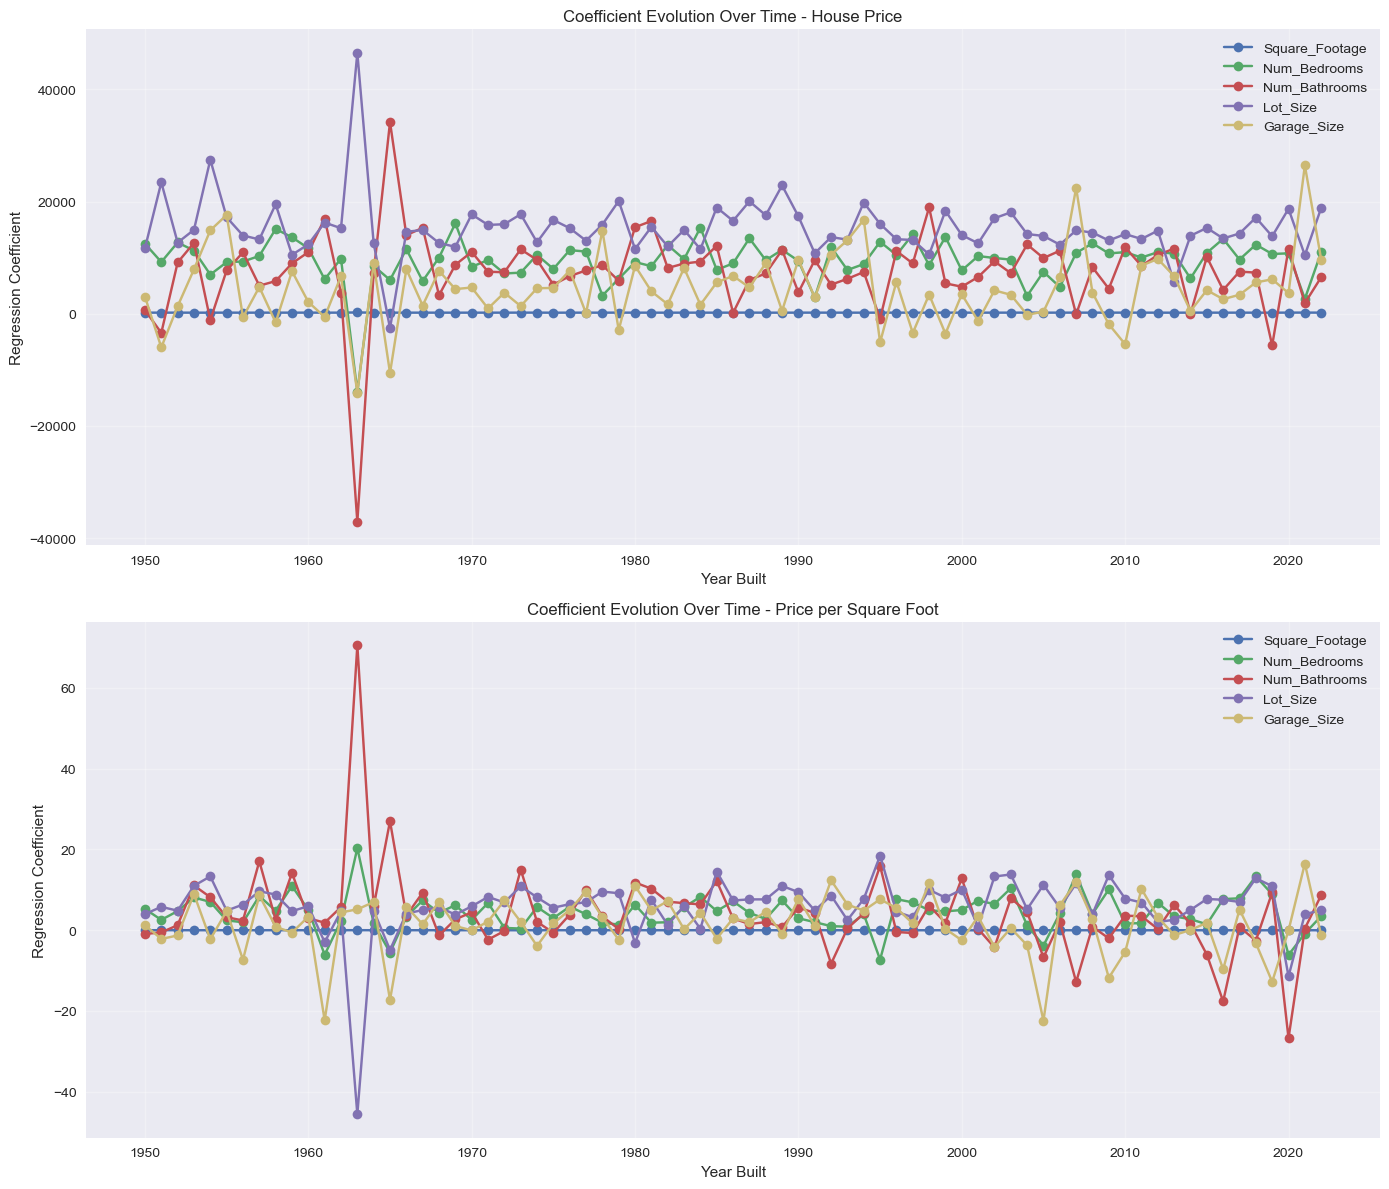

Coefficient evolution plot saved: coefficient_evolution_all.png


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

for ax, models_df, title in zip(
    axes, 
    [year_models_price, year_models_sqft],
    ['House Price', 'Price per Square Foot']
):
    for var in exog_vars:
        ax.plot(models_df.index, models_df[f'coef_{var}'], marker='o', label=var)
    
    ax.set_xlabel('Year Built')
    ax.set_ylabel('Regression Coefficient')
    ax.set_title(f'Coefficient Evolution Over Time - {title}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'coefficient_evolution_all.png', dpi=300, bbox_inches='tight')
plt.show()

print("Coefficient evolution plot saved: coefficient_evolution_all.png")

In [7]:
print("=== Trend Analysis of Coefficients Over Time ===")

def analyze_trend(models_df, title):
    print(f"\n--- {title} ---")
    for var in exog_vars:
        y = models_df[f'coef_{var}']
        x = models_df.index
        
        # Linear trend
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        
        # Goodness of fit
        y_pred = p(x)
        ss_tot = np.sum((y - np.mean(y))**2)
        ss_res = np.sum((y - y_pred)**2)
        r_squared = 1 - (ss_res / ss_tot)
        
        # F-test
        n = len(x)
        f_stat = (r_squared / 1) / ((1 - r_squared) / (n - 2))
        p_value = 1 - stats.f.cdf(f_stat, 1, n - 2)
        
        trend_output = f"{var:15} → y = {z[0]:.6f}x + {z[1]:.6f} | R² = {r_squared:.4f} | p-value = {p_value:.4f}"
        
        if p_value < 0.01:
            print(f"\033[91m{trend_output}  (Highly Significant)\033[0m")
        elif p_value < 0.05:
            print(f"\033[93m{trend_output}  (Significant)\033[0m")
        else:
            print(trend_output)

analyze_trend(year_models_price, "House Price")
analyze_trend(year_models_sqft, "Price per Square Foot")

=== Trend Analysis of Coefficients Over Time ===

--- House Price ---
Square_Footage  → y = 0.005860x + 189.149645 | R² = 0.0005 | p-value = 0.8448
Num_Bedrooms    → y = 11.283733x + -12966.510005 | R² = 0.0036 | p-value = 0.6117
Num_Bathrooms   → y = 1.393904x + 4714.347155 | R² = 0.0000 | p-value = 0.9741
Lot_Size        → y = -34.911624x + 84623.552872 | R² = 0.0189 | p-value = 0.2465
Garage_Size     → y = 44.364538x + -83644.143201 | R² = 0.0207 | p-value = 0.2248

--- Price per Square Foot ---
Square_Footage  → y = -0.000213x + 0.411283 | R² = 0.2780 | p-value = 0.0000  (Highly Significant)
Num_Bedrooms    → y = -0.001814x + 7.932730 | R² = 0.0001 | p-value = 0.9420
Num_Bathrooms   → y = -0.173189x + 348.021874 | R² = 0.1140 | p-value = 0.0035  (Highly Significant)
Lot_Size        → y = 0.050708x + -94.870916 | R² = 0.0199 | p-value = 0.2344
Garage_Size     → y = -0.010727x + 22.782787 | R² = 0.0010 | p-value = 0.7881


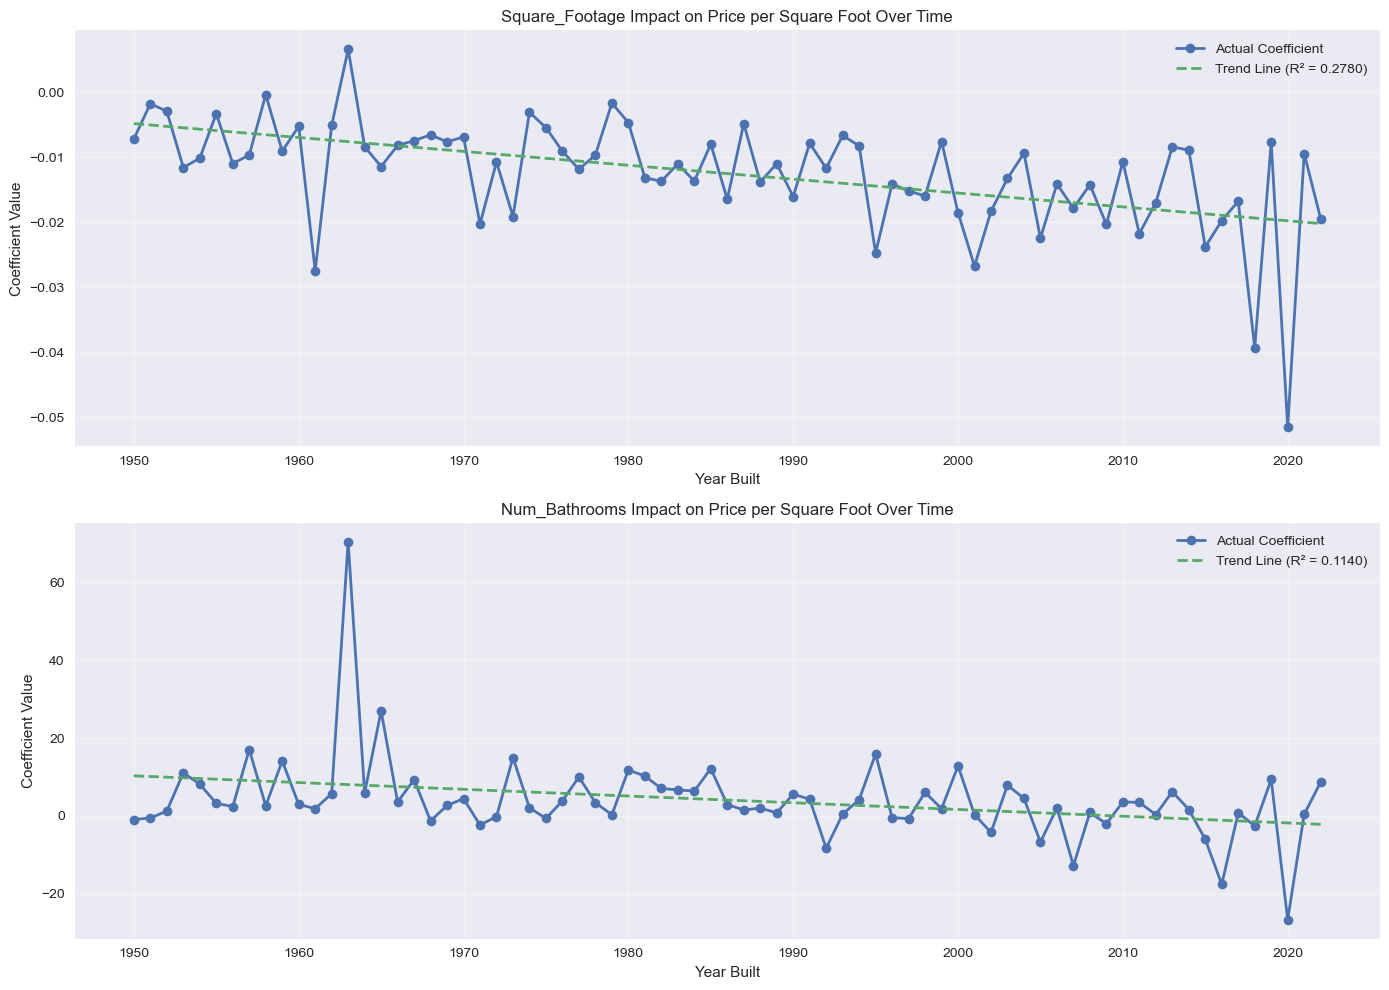

Significant coefficient trends plot saved: significant_coefficient_trends.png


In [8]:
# Focus on variables with significant trends in Price_Per_Sqft
significant_vars = ['Square_Footage', 'Num_Bathrooms']

fig, axes = plt.subplots(len(significant_vars), 1, figsize=(14, 10))

for idx, var in enumerate(significant_vars):
    y = year_models_sqft[f'coef_{var}']
    x = year_models_sqft.index
    
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    
    # Goodness of fit
    y_pred = p(x)
    r_squared = 1 - np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)
    
    axes[idx].plot(x, y, 'o-', label='Actual Coefficient', linewidth=2)
    axes[idx].plot(x, p(x), '--', label=f'Trend Line (R² = {r_squared:.4f})', linewidth=2)
    
    axes[idx].set_xlabel('Year Built')
    axes[idx].set_ylabel('Coefficient Value')
    axes[idx].set_title(f'{var} Impact on Price per Square Foot Over Time')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'significant_coefficient_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print("Significant coefficient trends plot saved: significant_coefficient_trends.png")

In [9]:
print("\n" + "="*80)
print("DYNAMIC COEFFICIENT ANALYSIS COMPLETE")
print("="*80)
print("""
Key Insights:
1. Most features show relatively stable coefficients for House_Price over time.
2. For Price_Per_Sqft, Square_Footage and Num_Bathrooms exhibit statistically significant 
   declining trends (negative slope), suggesting diminishing marginal effects in newer properties.
3. This implies that large floor area and additional bathrooms provide less premium 
   in more recently built houses.
""")
print("All figures have been saved to results/figures/")


DYNAMIC COEFFICIENT ANALYSIS COMPLETE

Key Insights:
1. Most features show relatively stable coefficients for House_Price over time.
2. For Price_Per_Sqft, Square_Footage and Num_Bathrooms exhibit statistically significant 
   declining trends (negative slope), suggesting diminishing marginal effects in newer properties.
3. This implies that large floor area and additional bathrooms provide less premium 
   in more recently built houses.

All figures have been saved to results/figures/
